# NLP Assignment 4: Fine-Tuning BERT on IMDB Dataset

## Objective
The objective of this assignment is to understand and implement BERT (Bidirectional Encoder Representations from Transformers) for text classification. The task involves fine-tuning a pre-trained BERT model on a real-world dataset and evaluating its performance.

## Dataset
The dataset used in this assignment is the IMDB Movie Reviews dataset obtained from Kaggle. It contains movie reviews labeled as positive or negative for sentiment classification.

## Methodology
The following steps were performed in this assignment:

1. **Data Preprocessing**
   - Removed HTML tags and special characters
   - Converted text to lowercase
   - Converted sentiment labels into numerical format

2. **Data Splitting**
   - Split the dataset into training, validation, and test sets

3. **Tokenization**
   - Used `bert-base-uncased` tokenizer
   - Converted text into tokenized format suitable for BERT

4. **Model Building**
   - Used pre-trained BERT model (`AutoModelForSequenceClassification`)
   - Configured model for binary classification

5. **Fine-Tuning**
   - Used AdamW optimizer with learning rate = 2e-5
   - Trained model on dataset using Hugging Face Trainer API

6. **Evaluation**
   - Evaluated model using:
     - Accuracy
     - Precision
     - Recall
     - F1 Score
   - Generated Confusion Matrix

7. **Experiments**
   - Experiment 1: Freezing BERT layers and training classifier
   - Experiment 2: Fine-tuning last 2 layers of BERT
   - Compared performance of both approaches

## Tools and Technologies Used
- Python
- Hugging Face Transformers
- PyTorch
- Scikit-learn
- Google Colab

## Expected Outcome
This assignment demonstrates how fine-tuning a pre-trained transformer model like BERT improves performance in text classification tasks compared to using frozen layers.

In [4]:
!pip install transformers torch seaborn scikit-learn

In [16]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

# reduce size (important)
df = df.sample(10000, random_state=42)

df.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [17]:
import re

def preprocess_review(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    return text

df['review'] = df['review'].apply(preprocess_review)

# label encoding
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

df = df[['review', 'label']]

In [18]:
from sklearn.model_selection import train_test_split

train_text, temp_text, train_labels, temp_labels = train_test_split(
    df['review'], df['label'], test_size=0.3, random_state=42
)

val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels, test_size=0.5
)

In [19]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(list(train_text), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_text), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_text), truncation=True, padding=True, max_length=128)

In [20]:
import torch

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
for param in model.bert.parameters():
    param.requires_grad = False

In [23]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results1',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="no"
)

trainer1 = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer1.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.695625


TrainOutput(global_step=875, training_loss=0.6931655970982142, metrics={'train_runtime': 3591.6434, 'train_samples_per_second': 1.949, 'train_steps_per_second': 0.244, 'total_flos': 460444346880000.0, 'train_loss': 0.6931655970982142, 'epoch': 1.0})

In [24]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pred1 = trainer1.predict(test_dataset)

y_pred1 = np.argmax(pred1.predictions, axis=1)
y_true = list(test_labels)

print("Experiment 1 Results:")
print("Accuracy:", accuracy_score(y_true, y_pred1))
print("Precision:", precision_score(y_true, y_pred1))
print("Recall:", recall_score(y_true, y_pred1))
print("F1 Score:", f1_score(y_true, y_pred1))

Experiment 1 Results:
Accuracy: 0.5326666666666666
Precision: 0.52
Recall: 0.8655126498002663
F1 Score: 0.6496751624187906


In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

# freeze all layers
for param in model.bert.parameters():
    param.requires_grad = False

# unfreeze last 2 layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
training_args = TrainingArguments(
    output_dir='./results2',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy="no"
)

trainer2 = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer2.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.433313


TrainOutput(global_step=875, training_loss=0.4009535435267857, metrics={'train_runtime': 4490.5835, 'train_samples_per_second': 1.559, 'train_steps_per_second': 0.195, 'total_flos': 460444346880000.0, 'train_loss': 0.4009535435267857, 'epoch': 1.0})

In [27]:
pred2 = trainer2.predict(test_dataset)

y_pred2 = np.argmax(pred2.predictions, axis=1)

print("Experiment 2 Results:")
print("Accuracy:", accuracy_score(y_true, y_pred2))
print("Precision:", precision_score(y_true, y_pred2))
print("Recall:", recall_score(y_true, y_pred2))
print("F1 Score:", f1_score(y_true, y_pred2))

Experiment 2 Results:
Accuracy: 0.8593333333333333
Precision: 0.8443877551020408
Recall: 0.881491344873502
F1 Score: 0.8625407166123779


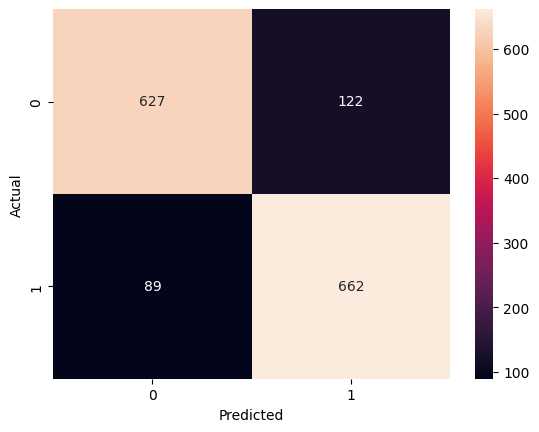

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred2)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()